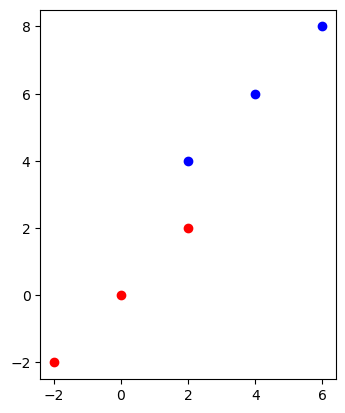

In [14]:
# 원본 데이터 -> 평균 제거 -> PCA 적용 -> 변환된 데이터
# 각 Feature의 평균을 빼서 데이터의 중심을 원점으로 옮기기

import matplotlib.pyplot as plt
import numpy as np

ax = plt.subplot(1,1,1, aspect='equal')
x = np.array([[2,4],[4,6],[6,8]])

ax.scatter(x[:,0], x[:,1], color='blue')
x -= x.mean(axis=0).astype(int)
ax.scatter(x[:,0], x[:,1], color='red')

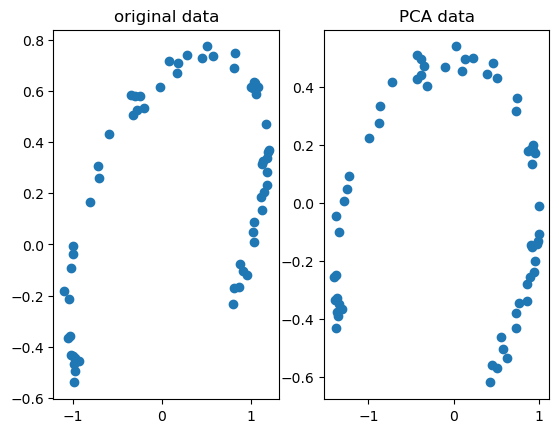

In [18]:
import numpy as np
np.random.seed(42)
m = 60

# 3차원데이터
w1, w2 = 0.1,0.3
noise = 0.1

angle = np.random.rand(m) * 3 * np.pi / 2 - 0.5
X = np.empty((m,3))

# 서로 약간 상관관계 있는 구조
X[:,0] = np.cos(angle) + np.sin(angle)/2 + noise*np.random.rand(m)
X[:,1] = np.sin(angle) * 0.7 + noise * np.random.rand(m)
X[:,2] = X[:,0] * w1 + X[:,1]*w2 + noise*np.random.rand(m)

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

# 변환 전 (X의 일부 차원만 시각화)
plt.subplot(1,2,1)
plt.scatter(X[:,0],X[:,1])
plt.title('original data')

# 변환 후
plt.subplot(1,2,2)
plt.scatter(X2D[:,0],X2D[:,1])
plt.title('PCA data')

plt.show()

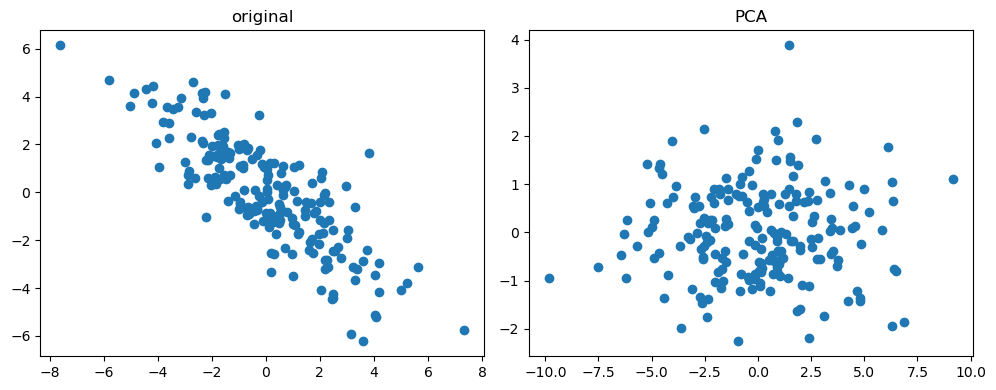

In [19]:
import numpy as np
from sklearn.decomposition import PCA

# 타원형 데이터 생성
m = 200

# 길게 늘어진 직선형태
X = np.random.randn(m,2)
X[:,0]*=3

# 회전 (기울기)
theta = np.pi /4    # 45도 회전
rotation_matrix = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])

X = X@rotation_matrix

# PCA 적용
pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

# 시각화
fig, ax = plt.subplots(1,2,figsize=(10,4))

ax[0].scatter(X[:,0], X[:,1])
ax[0].set_title('original')

ax[1].scatter(X2D[:,0], X2D[:,1])
ax[1].set_title('PCA')

plt.tight_layout()
plt.show()